In [92]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242)

features = energy_efficiency.data.features
selected_columns = energy_efficiency.data.targets
heating_column = selected_columns['Y1']
cooling_column = selected_columns['Y2']

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y1_train, y1_test = train_test_split(features, heating_column, test_size=0.2, random_state=1111)
_, _, y2_train, y2_test = train_test_split(features, cooling_column, test_size=0.2, random_state=1111)

In [94]:
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

def print_statistics(y_test, y_pred, model_name):
    print(f"\n{model_name}:")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

def plot(y_test, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Предсказания')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red',
    label='Идеальная линия')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(title)
    plt.legend()
    plt.show()

In [95]:
models_results = []


Linear Model (Y1):
MSE: 9.1250


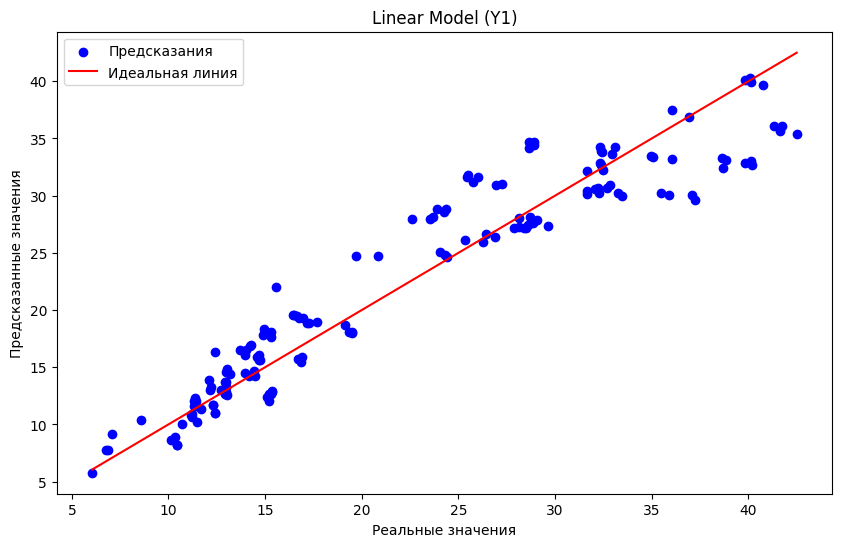


Linear Model (Y2):
MSE: 12.7634


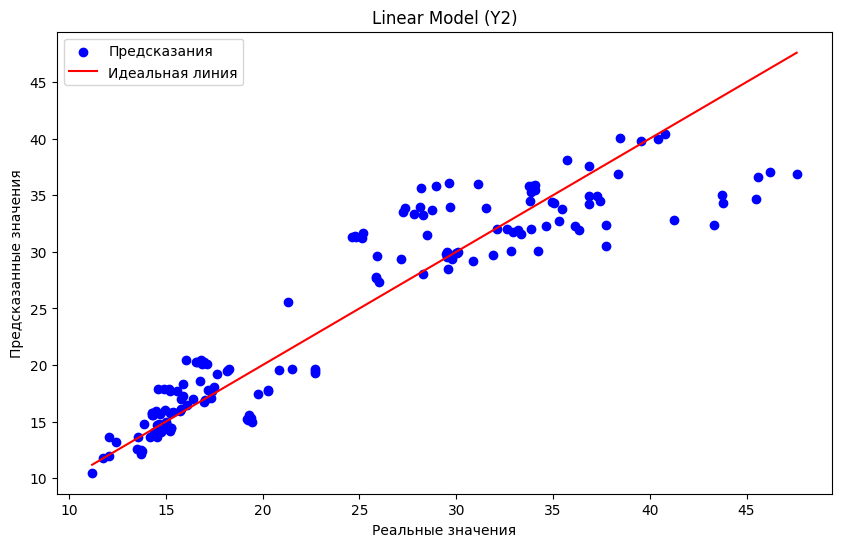

In [96]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y1_train)
y1_pred_lm = lm.predict(X_test)
print_statistics(y1_test, y1_pred_lm, "Linear Model (Y1)")
plot(y1_test, y1_pred_lm, "Linear Model (Y1)")

lm.fit(X_train, y2_train)
y2_pred_lm = lm.predict(X_test)
print_statistics(y2_test, y2_pred_lm, "Linear Model (Y2)")
plot(y2_test, y2_pred_lm, "Linear Model (Y2)")
models_results.append([[y1_test, y1_pred_lm], [y2_test, y2_pred_lm]])


Generalized Linear Model (Y1):
MSE: 9.1889


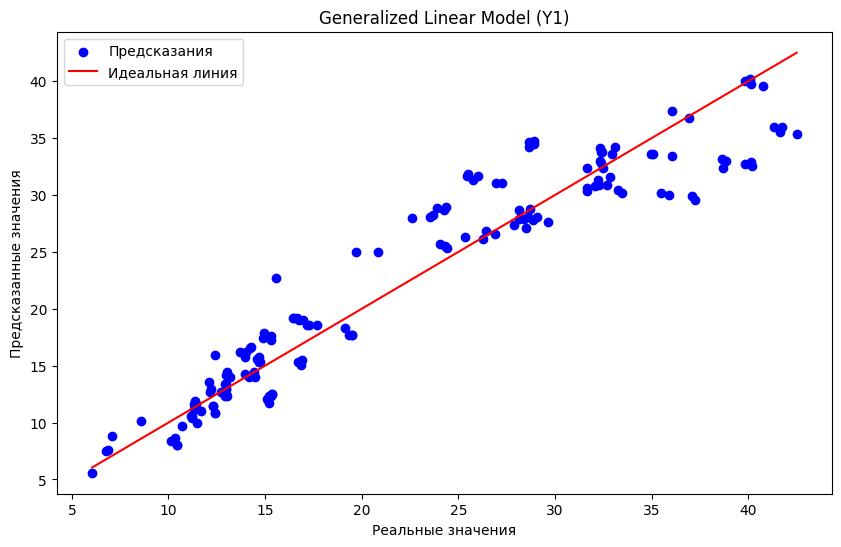


Generalized Linear Model (Y2):
MSE: 12.7426


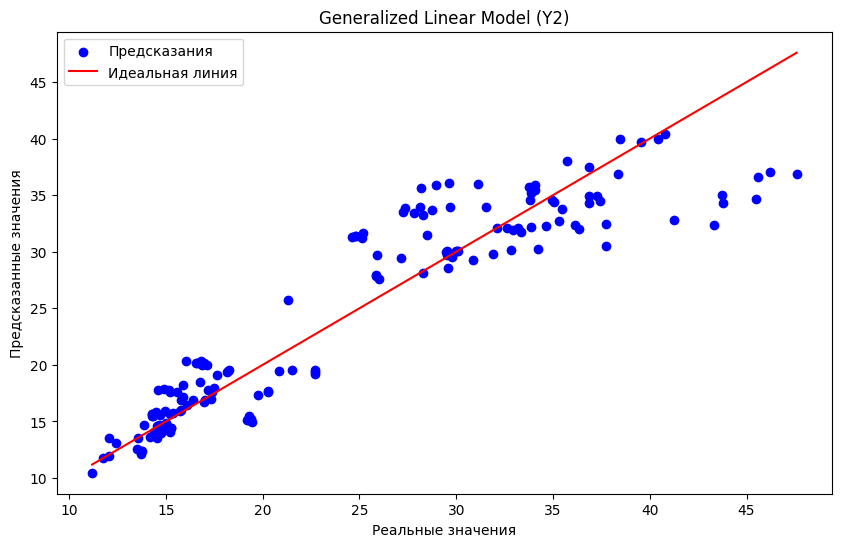

In [97]:
import statsmodels.api as sm

glm = sm.GLM(y1_train, sm.add_constant(X_train), family=sm.families.Gaussian())
res = glm.fit()
y1_pred_glm = res.predict(sm.add_constant(X_test))
print_statistics(y1_test, y1_pred_glm, "Generalized Linear Model (Y1)")
plot(y1_test, y1_pred_glm, "Generalized Linear Model (Y1)")

glm = sm.GLM(y2_train, sm.add_constant(X_train), family=sm.families.Gaussian())
res = glm.fit()
y2_pred_glm = res.predict(sm.add_constant(X_test))
print_statistics(y2_test, y2_pred_glm, "Generalized Linear Model (Y2)")
plot(y2_test, y2_pred_glm, "Generalized Linear Model (Y2)")
models_results.append([[y1_test, y1_pred_glm], [y2_test, y2_pred_glm]])


Non-linear Model (Y1):
MSE: 4.7880


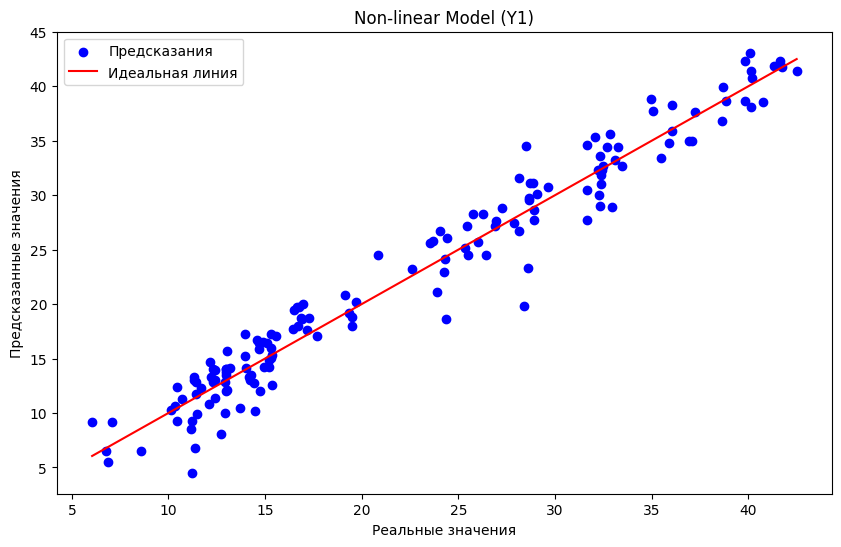


Non-linear Model (Y2):
MSE: 15.8828


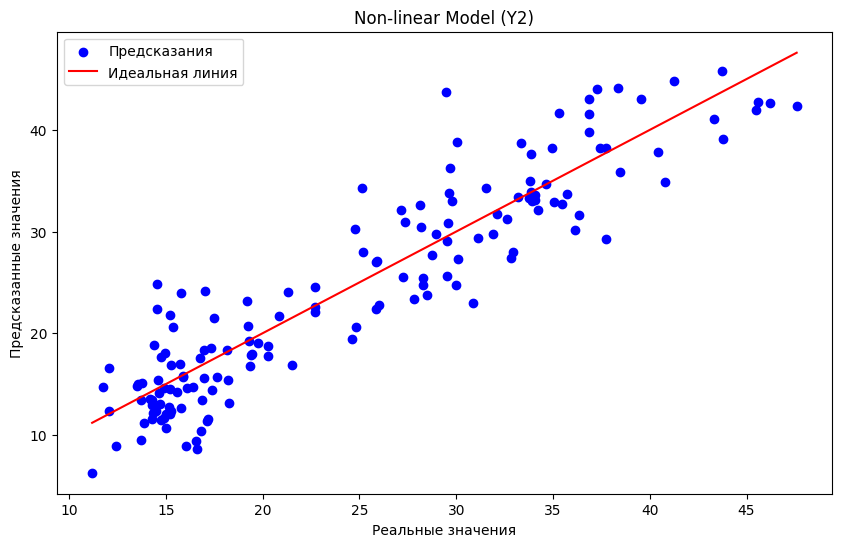

In [98]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y1_train)
y1_pred_nlm = poly_model.predict(X_test)
print_statistics(y1_test, y1_pred_nlm, "Non-linear Model (Y1)")
plot(y1_test, y1_pred_nlm, "Non-linear Model (Y1)")

poly_model.fit(X_train, y2_train)
y2_pred_nlm = poly_model.predict(X_test)
print_statistics(y2_test, y2_pred_nlm, "Non-linear Model (Y2)")
plot(y2_test, y2_pred_nlm, "Non-linear Model (Y2)")
models_results.append([[y1_test, y1_pred_nlm], [y2_test, y2_pred_nlm]])


Neural model (Y1):
MSE: 15.1661


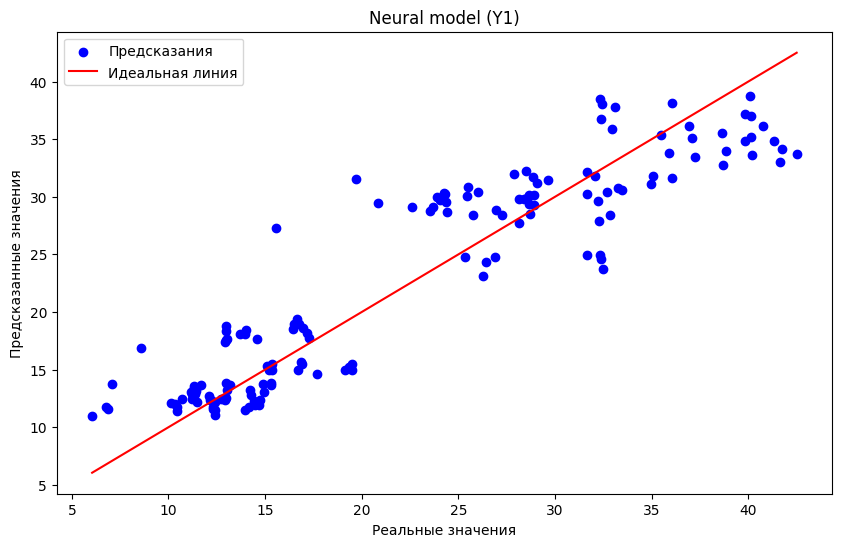


Neural model (Y2):
MSE: 16.3545


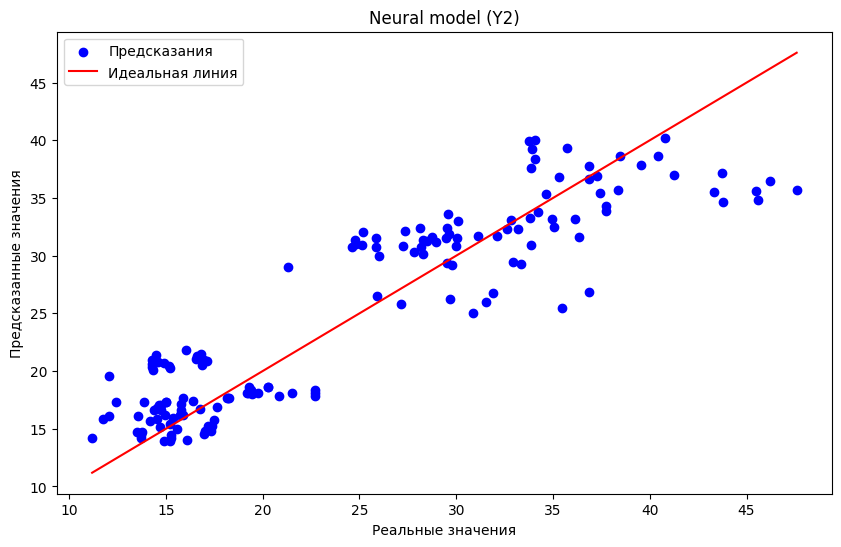

In [99]:
from sklearn.neural_network import MLPRegressor

mlp_reg = MLPRegressor(hidden_layer_sizes=(10), activation='relu', solver='adam', max_iter=10000, random_state=1)
mlp_reg.fit(X_train, y1_train)
y1_pred_neuro = mlp_reg.predict(X_test)
print_statistics(y1_test, y1_pred_neuro, "Neural model (Y1)")
plot(y1_test, y1_pred_neuro, "Neural model (Y1)")

mlp_reg.fit(X_train, y2_train)
y2_pred_neuro = mlp_reg.predict(X_test)
print_statistics(y2_test, y2_pred_neuro, "Neural model (Y2)")
plot(y2_test, y2_pred_neuro, "Neural model (Y2)")
models_results.append([[y1_test, y1_pred_neuro], [y2_test, y2_pred_neuro]])

In [100]:
from sklearn.metrics import max_error, mean_absolute_error, mean_absolute_percentage_error

def metrics(y_test, y_pred):
    return {
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'Max Error': max_error(y_test, y_pred)
    }

In [101]:
y1MSEs = []
y2MSEs = []

def create_table(columns, models, metrics_list, outside_data):
    data = []

    for index, model in enumerate(models):
        for metric in metrics_list:
            #outside_data.append([[y1_test, y1_pred_lm], [y2_test, y2_pred_lm]])  
            current_model = outside_data[index]
            current_y1_test = current_model[0][0]
            current_y1_pred = current_model[0][1]
            current_y2_test = current_model[1][0]
            current_y2_pred = current_model[1][1]

            if metric == 'MSE':
                y1MSEs.append({model: metrics(current_y1_test, current_y1_pred)[metric]})
                y2MSEs.append({model: metrics(current_y2_test, current_y2_pred)[metric]})

            data.append([
                model, metric, 
                metrics(current_y1_test, current_y1_pred)[metric], 
                metrics(current_y2_test, current_y2_pred)[metric]
            ])

    return pd.DataFrame(data, columns=columns)

In [102]:
models = ['lm', 'glm', 'nlm', 'neuro']
metrics_list = ['MSE', 'MAE', 'MAPE', 'Max Error']
columns = ['Model', 'Metric', 'Y1', 'Y2']
table = create_table(columns=columns, models=models, metrics_list=metrics_list, outside_data=models_results)
table

,Model,Metric,Y1,Y2
0,lm,MSE,9.124958,12.763421
1,lm,MAE,2.261153,2.561299
2,lm,MAPE,0.105093,0.101330
3,lm,Max Error,7.632301,10.913348
4,glm,MSE,9.188936,12.742584
5,glm,MAE,2.223829,2.545584
6,glm,MAPE,0.102790,0.100454
7,glm,Max Error,7.723707,10.923916
8,nlm,MSE,4.787953,15.882776
9,nlm,MAE,1.702710,3.183131


In [103]:
def min_value(arr):
    min_model = None
    min_value = float('inf')

    for dict in arr:
        for model, value in dict.items():
            if (model == 'nlm'):
                continue

            if value < min_value:
                min_value = value
                min_model = model

    return {min_model: min_value}

In [104]:
print(f"Smallest MSE for Heating Load: {min_value(y1MSEs)}")
print(f"Smallest MSE for Cooling Load: {min_value(y2MSEs)}")

Smallest MSE for Heating Load: {'lm': np.float64(9.124958496937566)}
Smallest MSE for Cooling Load: {'glm': np.float64(12.74258387753127)}


In [105]:
outside_data = []
outside_data.append([[y1_test, y1_pred_lm],[y2_test, y2_pred_lm]])

In [106]:
def weights(y_test, y_pred):
    return 1 / (1 + abs((y_test - y_pred) / y_test))

Quantile Y1 MAPE: 0.10119362282748673


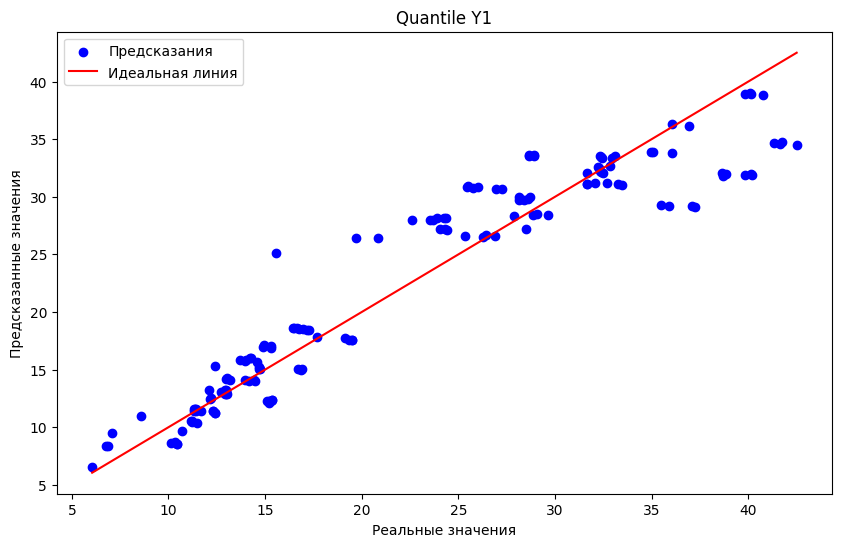

Quantile Y2 MAPE: 0.09557864641448229


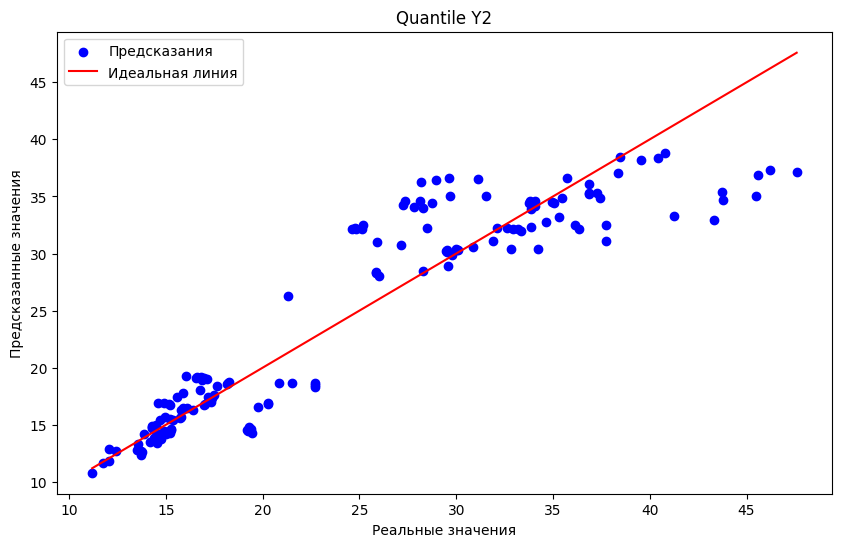

In [107]:
from sklearn.linear_model import QuantileRegressor

lm.fit(X_train, y1_train)
initial_y1_pred = lm.predict(X_train)
weights_y1 = weights(y_test=y1_train, y_pred=initial_y1_pred)

qr = QuantileRegressor(quantile=0.5, alpha=0.001)
qr.fit(X_train, y1_train, sample_weight=weights_y1)
qr_y1_pred = qr.predict(X_test)
qr_y1_MAPE = mean_absolute_percentage_error(y1_test, qr_y1_pred)
print(f"Quantile Y1 MAPE: {qr_y1_MAPE}")
plot(y1_test, qr_y1_pred, "Quantile Y1")

lm.fit(X_train, y2_train)
initial_y2_pred = lm.predict(X_train)
weights_y2 = weights(y_test=y2_train, y_pred=initial_y2_pred)

qr.fit(X_train, y2_train, sample_weight=weights_y2)
qr_y2_pred = qr.predict(X_test)
qr_y2_MAPE = mean_absolute_percentage_error(y2_test, qr_y2_pred)
print(f"Quantile Y2 MAPE: {qr_y2_MAPE}")
plot(y2_test, qr_y2_pred, "Quantile Y2")

outside_data.append([[y1_test, qr_y1_pred],[y2_test, qr_y2_pred]])

In [108]:
import numpy as np

def l1_loss(params, X, y):
    y_pred = np.dot(sm.add_constant(X), params)
    return np.sum(np.abs(y - y_pred)) 

Optimised params Y1: [ 8.99107194e+01 -6.93375009e+01  1.39481558e+12 -1.39481558e+12
 -2.78963116e+12  4.12433441e+00 -1.53490432e-02  2.01157497e+01
  2.20096412e-01]


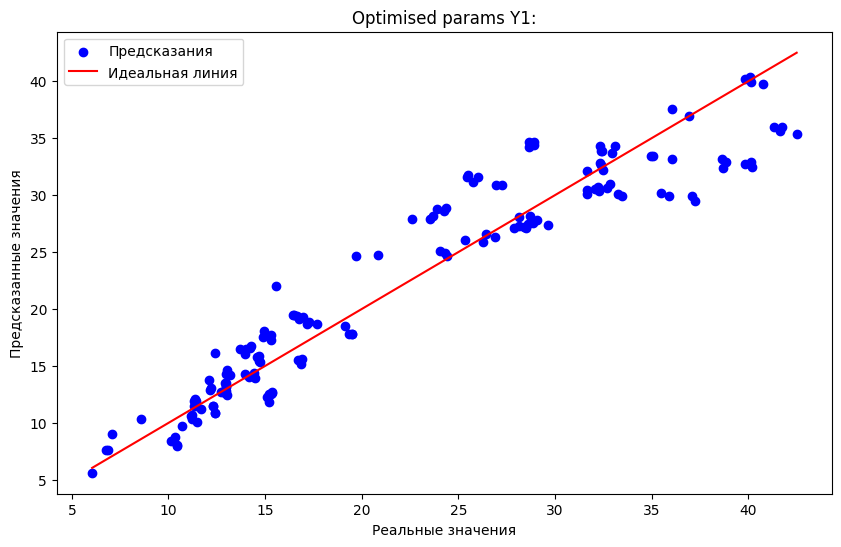

In [109]:
from scipy.optimize import minimize

lm = LinearRegression()
lm.fit(X_train, y1_train)
initial_params_y1 = np.append(lm.intercept_, lm.coef_)
y1_l1 = minimize(fun=l1_loss, x0=initial_params_y1, args=(X_train, y1_train), method='L-BFGS-B').x
res = np.dot(sm.add_constant(X_test), y1_l1)
print(f"Optimised params Y1: {y1_l1}")
plot(y1_test, res, "Optimised params Y1:")


Optimised params Y2: [ 9.24006868e+01 -6.87562576e+01  3.76492834e+11 -3.76492834e+11
 -7.52985669e+11  4.34922338e+00  1.65393854e-01  1.49877886e+01
  6.11704939e-02]


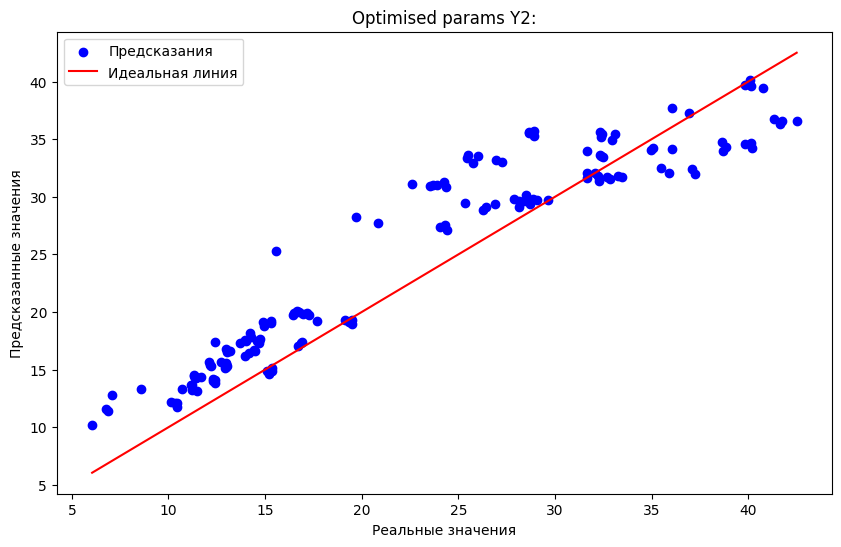

In [110]:
lm = LinearRegression()
lm.fit(X_train, y2_train)
initial_params_y2 = np.append(lm.intercept_, lm.coef_)
y2_l1 = minimize(fun=l1_loss, x0=initial_params_y2, args=(X_train, y2_train), method='L-BFGS-B').x
res = np.dot(sm.add_constant(X_test), y2_l1)
print(f"Optimised params Y2: {y2_l1}")
plot(y1_test, res, "Optimised params Y2:")

outside_data.append([[y1_test, y1_l1],[y2_test, y2_l1]])

In [111]:
models = ['lm', 'quantile', 'optimised']
metrics_list = ['MSE', 'MAE', 'MAPE', 'Max Error']
columns = ['Model', 'Metric', 'Y1', 'Y2']
table = create_table(columns=columns, models=models, metrics_list=metrics_list, outside_data=models_results)
table

,Model,Metric,Y1,Y2
0,lm,MSE,9.124958,12.763421
1,lm,MAE,2.261153,2.561299
2,lm,MAPE,0.105093,0.101330
3,lm,Max Error,7.632301,10.913348
4,quantile,MSE,9.188936,12.742584
5,quantile,MAE,2.223829,2.545584
6,quantile,MAPE,0.102790,0.100454
7,quantile,Max Error,7.723707,10.923916
8,optimised,MSE,4.787953,15.882776
9,optimised,MAE,1.702710,3.183131
